# General chemical reactions

`ReactionSystem` adds arbitrary stoichiometric reactions and chemostatted species to the Model-B solver. Examples cover dimerization, a Schlögl model, enzyme-driven droplets, and a Michaelis-Menten-style turnover check.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jax_phase_separation.utils import (
    generate_chi_matrix, generate_initial_conditions,
    build_params, plot_volume_fractions,
)
from jax_phase_separation.solver import simulate, simulate_with_snapshots
from jax_phase_separation.reactions import (
    ReactionSystem, build_reaction_system, linear_turnover_system,
    empty_reaction_system,
)

print('JAX version:', jax.__version__, '  devices:', jax.devices())

JAX version: 0.6.0   devices: [CpuDevice(id=0)]


In [2]:
# XLA warmup on a tiny grid with an empty reaction system.
_chi = generate_chi_matrix(3, 0.0, 1.0, jax.random.PRNGKey(0))
_c0 = generate_initial_conditions(3, 16, key=jax.random.PRNGKey(0))
_rxn = empty_reaction_system(3)
_p = build_params(_chi, 3, lmbda=0.01, dt=5e-6, reactions=_rxn)
_ = simulate(_c0, _p, 16, 10).block_until_ready()
print('warmup done')

warmup done


## Example A: dimerization $2A \rightleftharpoons D$

Two internal species, with `chi` chosen so the dimer separates more strongly than the monomer.

In [3]:
N_COM = 2
N_GRID = 96
LMBDA = 0.01
DT = 5e-6
BETA = N_COM / (N_COM + 1.0)
N_STEPS = 30_000

# Dimer separates more strongly than monomer.
chi_A = jnp.array([[0.0, 1.0],
                   [1.0, 0.0]]) * 2.0

# Reversible dimerization: 2 A -> D.
dimer_rxn = build_reaction_system(
    reactions=[
        {'reactants': {0: 2}, 'products': {1: 1}, 'k_plus': 40.0, 'k_minus': 8.0},
    ],
    n_com=N_COM,
)
print('nu_plus =', np.asarray(dimer_rxn.nu_plus).T)
print('nu_minus=', np.asarray(dimer_rxn.nu_minus).T)
print('S =', np.asarray(dimer_rxn.nu_minus - dimer_rxn.nu_plus).T)

nu_plus = [[2. 0.]]
nu_minus= [[0. 1.]]
S = [[-2.  1.]]


In [4]:
key = jax.random.PRNGKey(101)
c0_A = generate_initial_conditions(N_COM, N_GRID, beta=BETA, noise_strength=0.1, key=key)
params_A = build_params(chi_A, N_COM, beta=BETA, lmbda=LMBDA, dt=DT,
                        reactions=dimer_rxn)

cf_A = simulate(c0_A, params_A, N_GRID, N_STEPS, rate_law='mass_action')
print('finite?', bool(jnp.all(jnp.isfinite(cf_A))))
print('mean A =', float(cf_A[0].mean()), '  mean D =', float(cf_A[1].mean()))
print('spatial std A, D =', float(cf_A[0].std()), float(cf_A[1].std()))


finite? True
mean A = 0.2703471779823303   mean D = 0.3648932874202728
spatial std A, D = 1.4404586181626655e-05 2.2766424081055447e-05


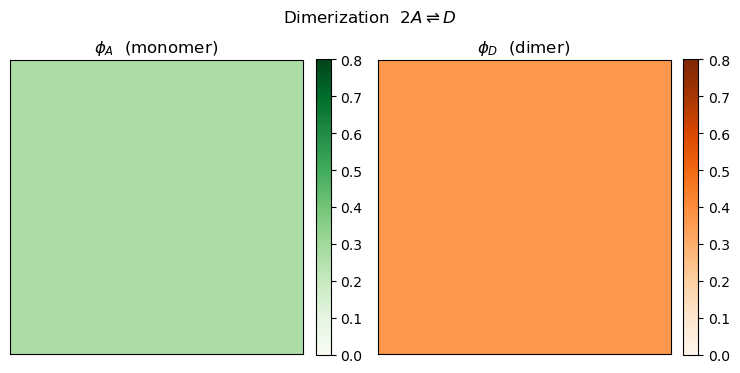

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))
titles = [r'$\phi_A$  (monomer)', r'$\phi_D$  (dimer)']
cmaps = ['Greens', 'Oranges']
for ax, phi, title, cmap in zip(axes, np.asarray(cf_A), titles, cmaps):
    im = ax.imshow(phi, cmap=cmap, origin='lower', vmin=0.0, vmax=0.8)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(r'Dimerization  $2A \rightleftharpoons D$')
fig.tight_layout()
plt.show()

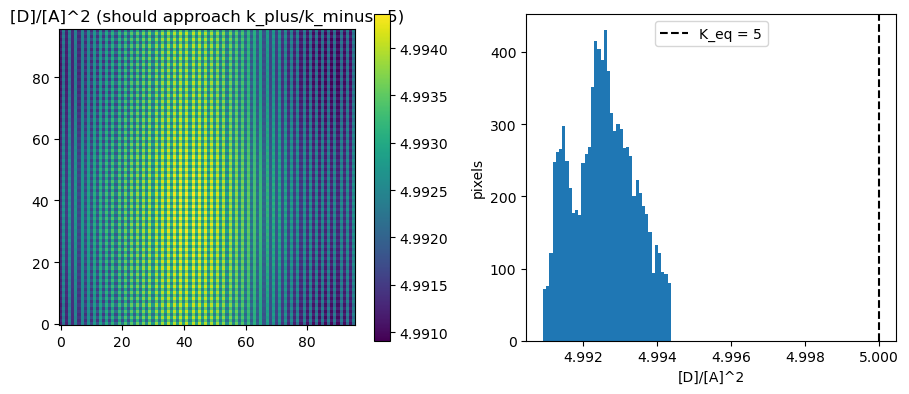

In [6]:
# Check the local mass-action ratio [D]/[A]^2 across the grid.
A_, D_ = np.asarray(cf_A[0]), np.asarray(cf_A[1])
ratio = D_ / np.maximum(A_**2, 1e-12)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
im0 = ax[0].imshow(ratio, origin='lower', cmap='viridis')
plt.colorbar(im0, ax=ax[0]); ax[0].set_title('[D]/[A]^2 (should approach k_plus/k_minus=5)')

ax[1].hist(ratio.flatten(), bins=40)
ax[1].axvline(5.0, color='k', ls='--', label='K_eq = 5')
ax[1].set_xlabel('[D]/[A]^2'); ax[1].set_ylabel('pixels')
ax[1].legend()
fig.tight_layout(); plt.show()

## Example B: Schlögl model

$$2X + Y_a \rightleftharpoons 3X, \qquad X \rightleftharpoons Y_b.$$

Only $X$ is tracked. The chemostatted species set the bistable branch; with `chi = 0`, long-time states are spatially uniform.

In [7]:
N_COM_B = 1
N_GRID_B = 96
LMBDA_B = 0.01
DT_B = 2e-6
BETA_B = 0.6
N_STEPS_B = 20_000

# chi is zero: no multicomponent demixing. Spatial texture would require more
# species or nonzero chi; here the sweep varies the homogeneous level of X.
chi_B = jnp.zeros((N_COM_B, N_COM_B))

def make_schlogl(mu_a: float, mu_b: float) -> ReactionSystem:
    rxns = [
        # 2X + Y_a  <->  3X
        {'reactants': {0: 2, 'Y0': 1}, 'products': {0: 3},
         'a': 1.0, 'k_plus': 1.0, 'k_minus': 1.0},
        #    X     <->  Y_b
        {'reactants': {0: 1}, 'products': {'Y1': 1},
         'a': 0.5, 'k_plus': 1.0, 'k_minus': 1.0},
    ]
    return build_reaction_system(rxns, n_com=N_COM_B, n_ex=2,
                                 mu_ex=jnp.array([mu_a, mu_b]))

demo_rxn = make_schlogl(mu_a=1.0, mu_b=-1.0)
print('nu_plus (internal) =', np.asarray(demo_rxn.nu_plus))
print('nu_minus(internal) =', np.asarray(demo_rxn.nu_minus))
print('nu_plus (ext)      =', np.asarray(demo_rxn.nu_plus_ex))
print('nu_minus(ext)      =', np.asarray(demo_rxn.nu_minus_ex))


nu_plus (internal) = [[2. 1.]]
nu_minus(internal) = [[3. 0.]]
nu_plus (ext)      = [[1. 0.]
 [0. 0.]]
nu_minus(ext)      = [[0. 0.]
 [0. 1.]]


In [8]:
key = jax.random.PRNGKey(202)
c0_B = generate_initial_conditions(N_COM_B, N_GRID_B, beta=BETA_B,
                                   noise_strength=0.3, key=key)

mu_a_values = [-0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
finals_B = []

for mu_a in mu_a_values:
    rxn = make_schlogl(mu_a=float(mu_a), mu_b=-1.0)
    params = build_params(chi_B, N_COM_B, beta=BETA_B, lmbda=LMBDA_B, dt=DT_B,
                          reactions=rxn)
    cf = simulate(c0_B, params, N_GRID_B, N_STEPS_B, rate_law='thermodynamic')
    finals_B.append(np.asarray(cf))
    x = cf[0]
    print(f'mu_a = {mu_a:+.2f}   <X> = {float(x.mean()):.3f}   std_spatial(X) = {float(x.std()):.3f}')


mu_a = -0.50   <X> = 0.535   std_spatial(X) = 0.000
mu_a = +0.00   <X> = 0.554   std_spatial(X) = 0.000
mu_a = +0.50   <X> = 0.593   std_spatial(X) = 0.000
mu_a = +1.00   <X> = 0.685   std_spatial(X) = 0.000
mu_a = +1.50   <X> = 0.814   std_spatial(X) = 0.000
mu_a = +2.00   <X> = 0.880   std_spatial(X) = 0.000


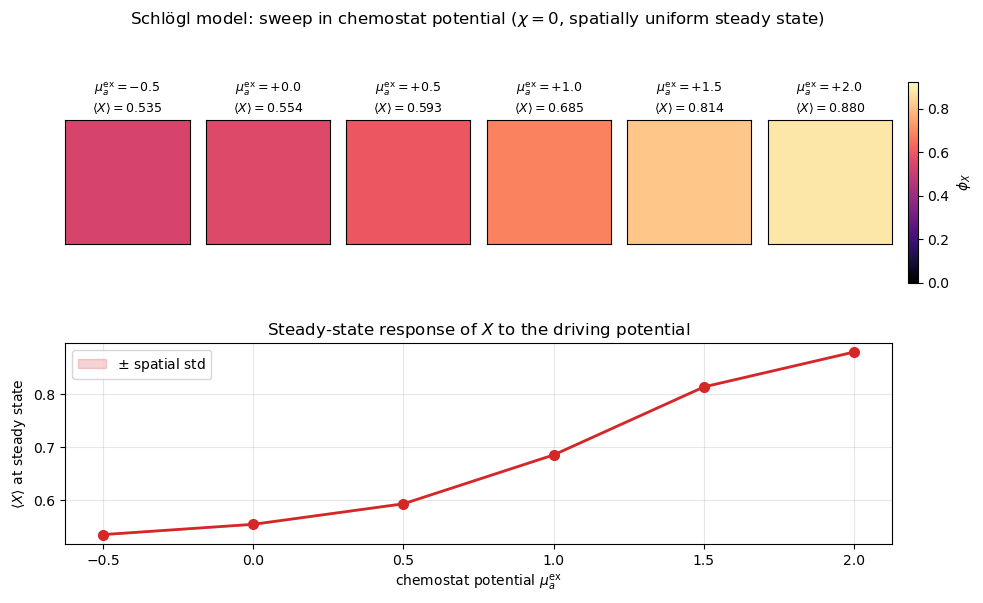

In [9]:
x_stack = np.stack([cf[0] for cf in finals_B])      # (n_mu, Ny, Nx)
x_mean = x_stack.mean(axis=(-1, -2))                # one number per mu_a
x_std = x_stack.std(axis=(-1, -2))

vmin = 0.0
vmax = float(x_stack.max()) * 1.05                  # shared across panels

fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 7, width_ratios=[1, 1, 1, 1, 1, 1, 0.08],
                      height_ratios=[1.0, 1.0], wspace=0.15, hspace=0.3)

for j, (mu_a, cf) in enumerate(zip(mu_a_values, finals_B)):
    ax = fig.add_subplot(gs[0, j])
    im = ax.imshow(cf[0], cmap='magma', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(fr'$\mu^{{\mathrm{{ex}}}}_a = {mu_a:+.1f}$' + '\n'
                 fr'$\langle X\rangle = {x_mean[j]:.3f}$', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

cax = fig.add_subplot(gs[0, 6])
plt.colorbar(im, cax=cax, label=r'$\phi_X$')

ax_line = fig.add_subplot(gs[1, :6])
ax_line.plot(mu_a_values, x_mean, 'o-', color='C3', lw=2, ms=7)
ax_line.fill_between(mu_a_values, x_mean - x_std, x_mean + x_std,
                     alpha=0.2, color='C3', label=r'$\pm$ spatial std')
ax_line.set_xlabel(r'chemostat potential $\mu^{\mathrm{ex}}_a$')
ax_line.set_ylabel(r'$\langle X\rangle$ at steady state')
ax_line.set_title(r'Steady-state response of $X$ to the driving potential')
ax_line.grid(True, alpha=0.3)
ax_line.legend(loc='upper left')

fig.suptitle('Schlögl model: sweep in chemostat potential '
             r'($\chi=0$, spatially uniform steady state)', y=1.0)
plt.show()


## Example C: enzyme-driven active droplets

$$E + S \rightleftharpoons ES \to E + P.$$

A fed substrate and drained product create an open cycle. The rates below are kept moderate to avoid exhausting the solvent fraction.

In [10]:
N_COM_C = 4
N_GRID_C = 96
LMBDA_C = 0.01
DT_C = 5e-6
BETA_C = 0.75  # headroom: chemostat feed increases total solute; keep sum_i phi_i < 1
R_MU_C = 12.0
N_STEPS_C = 72_000
SAVE_EVERY_C = 6_000

# Open chemostats (Y0 -> S, P -> Y1) change total internal mass. If feed outruns
# catalysis + waste, sum_i phi_i -> 1, solvent fraction hits the floor, and the
# FFT fluxes diverge (NaNs). Keep K_FEED modest and K_WASTE relatively fast.

chi_C = jnp.array([
    [ 0.0,  2.5, -4.0,  2.5],
    [ 2.5,  0.0,  2.5,  0.0],
    [-4.0,  2.5,  0.0,  2.5],
    [ 2.5,  0.0,  2.5,  0.0],
])

K_FEED, K_WASTE = 1.0, 40.0

enzyme_rxn = build_reaction_system(
    reactions=[
        {'reactants': {0: 1, 1: 1}, 'products': {2: 1},
         'k_plus': 35.0, 'k_minus': 5.0},
        {'reactants': {2: 1}, 'products': {0: 1, 3: 1},
         'k_plus': 15.0, 'k_minus': 0.0},
        {'reactants': {'Y0': 1}, 'products': {1: 1},
         'k_plus': K_FEED, 'k_minus': 0.15 * K_FEED},
        {'reactants': {3: 1}, 'products': {'Y1': 1},
         'k_plus': K_WASTE, 'k_minus': 0.0},
    ],
    n_com=N_COM_C,
    n_ex=2,
    mu_ex=jnp.zeros(2),
)

key = jax.random.PRNGKey(303)
c0_C = generate_initial_conditions(N_COM_C, N_GRID_C, beta=BETA_C,
                                   noise_strength=0.05, key=key)
yy, xx = jnp.mgrid[:N_GRID_C, :N_GRID_C]
cx, cy = N_GRID_C // 2, N_GRID_C // 2
r2 = (xx - cx) ** 2 + (yy - cy) ** 2
bump = jnp.exp(-r2 / (2 * 4.0 ** 2)) * 0.06
c0_C = c0_C.at[0].add(bump)
tot = c0_C.sum(axis=0, keepdims=True)
c0_C = c0_C * (BETA_C / tot)

params_C = build_params(chi_C, N_COM_C, beta=BETA_C, lmbda=LMBDA_C, dt=DT_C,
                        reactions=enzyme_rxn, r_mu=R_MU_C)
cf_C, snaps_C = simulate_with_snapshots(
    c0_C, params_C, N_GRID_C, N_STEPS_C, save_every=SAVE_EVERY_C,
    rate_law='mass_action',
)
print('finite?', bool(jnp.all(jnp.isfinite(cf_C))))
print('max sum_i phi_i (need < 1):', float(jnp.max(jnp.sum(cf_C, axis=0))))
print('means:', [float(cf_C[i].mean()) for i in range(N_COM_C)])
print('spatial std:', [float(cf_C[i].std()) for i in range(N_COM_C)])
print('snapshots shape:', snaps_C.shape)


finite? True
max sum_i phi_i (need < 1): 0.8383929133415222
means: [0.3402447998523712, 0.309455931186676, 0.04087432101368904, 0.015493742190301418]
spatial std: [0.2905775010585785, 0.287486732006073, 0.04560353606939316, 0.009394653141498566]
snapshots shape: (12, 4, 96, 96)


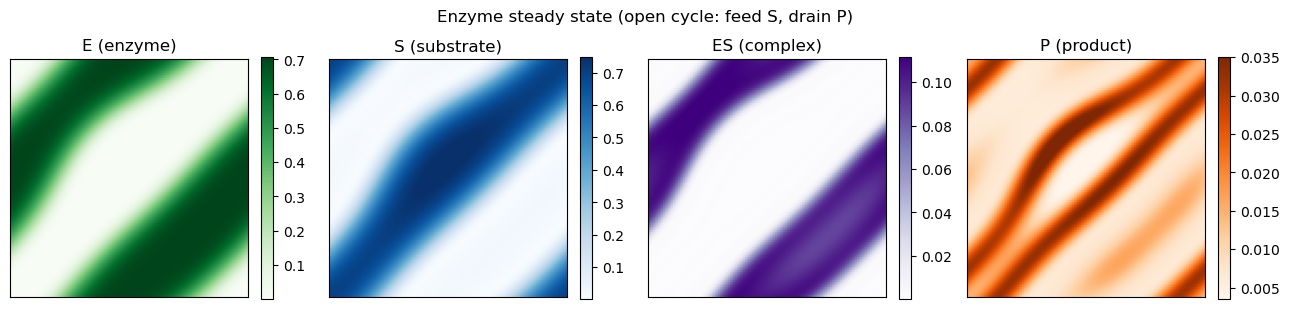

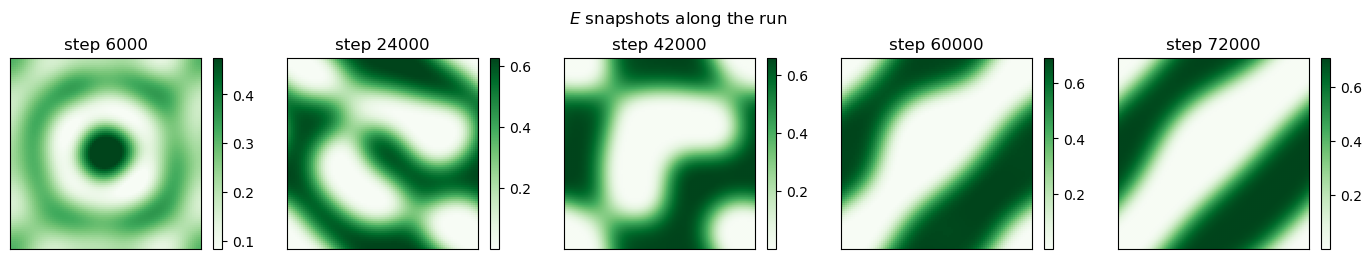

In [11]:
def _imshow_scaled(ax, cf_sp, label, cm):
    arr = np.asarray(cf_sp, dtype=np.float64)
    if not np.all(np.isfinite(arr)):
        ax.set_facecolor('0.85')
        ax.text(0.5, 0.5, 'non-finite\ndata', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_title(label)
        ax.set_xticks([]); ax.set_yticks([])
        return
    # clip numerical negatives; then robust contrast (percentiles on [0, inf))
    arr = np.clip(arr, 0.0, None)
    lo, hi = np.percentile(arr, [2.0, 98.0])
    if hi <= lo + 1e-12:
        lo, hi = float(np.min(arr)), float(np.max(arr))
        if hi <= lo + 1e-12:
            hi = lo + 1e-9
    im = ax.imshow(arr, origin='lower', cmap=cm, vmin=lo, vmax=hi)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
labels = ['E (enzyme)', 'S (substrate)', 'ES (complex)', 'P (product)']
cmaps  = ['Greens', 'Blues', 'Purples', 'Oranges']
for ax, cf_sp, label, cm in zip(axes, np.asarray(cf_C), labels, cmaps):
    _imshow_scaled(ax, cf_sp, label, cm)
fig.suptitle('Enzyme steady state (open cycle: feed S, drain P)')
fig.tight_layout(); plt.show()

n_snaps = snaps_C.shape[0]
idxs = [0, n_snaps // 4, n_snaps // 2, 3 * n_snaps // 4, n_snaps - 1]
fig2, axes2 = plt.subplots(1, len(idxs), figsize=(2.8 * len(idxs), 2.6))
for ax, j in zip(axes2, idxs):
    fld = np.asarray(snaps_C[j, 0], dtype=np.float64)
    if not np.all(np.isfinite(fld)):
        ax.set_facecolor('0.85')
        ax.text(0.5, 0.5, 'non-finite', ha='center', va='center', transform=ax.transAxes)
    else:
        fld = np.clip(fld, 0.0, None)
        lo, hi = np.percentile(fld, [2.0, 98.0])
        if hi <= lo + 1e-12:
            lo, hi = float(np.min(fld)), float(np.max(fld))
            if hi <= lo + 1e-12:
                hi = lo + 1e-9
        im = ax.imshow(fld, origin='lower', cmap='Greens', vmin=lo, vmax=hi)
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'step {(j + 1) * SAVE_EVERY_C}')
    ax.set_xticks([]); ax.set_yticks([])
fig2.suptitle(r'$E$ snapshots along the run')
fig2.tight_layout(); plt.show()


## Example D: Michaelis-Menten turnover

Approximate saturating turnover with elementary reactions and compare the linear limit against the legacy `kon`/`koff` source.

In [18]:
# Two internal species: S and C.
# Compare a linear turnover limit with a pseudo-elementary saturating case.

N_COM_D = 2
N_GRID_D = 64
LMBDA_D = 0.01
DT_D = 1e-6
BETA_D = N_COM_D / (N_COM_D + 1.0)
N_STEPS_D = 10_000

chi_D = jnp.array([[0.0, 3.0], [3.0, 0.0]])

# Linear limit: S -> C and C -> S.
kon_eff = 2.0
koff_eff = 5.0

linear_rxn = build_reaction_system(
    reactions=[
        {'reactants': {0: 1}, 'products': {1: 1}, 'k_plus': kon_eff, 'k_minus': 0.0},
        {'reactants': {1: 1}, 'products': {0: 1}, 'k_plus': koff_eff, 'k_minus': 0.0},
    ],
    n_com=N_COM_D,
)

# Saturating approximation uses a chemostatted enzyme species.
Vmax, Km = 5.0, 0.05
mm_rxn = build_reaction_system(
    reactions=[
        # Pseudo-elementary saturating turnover.
        {'reactants': {0: 2}, 'products': {1: 1}, 'k_plus': 2.0 * Vmax, 'k_minus': 0.0},
        {'reactants': {1: 1}, 'products': {0: 1}, 'k_plus': koff_eff,    'k_minus': 0.0},
    ],
    n_com=N_COM_D,
)

key = jax.random.PRNGKey(404)
c0_D = generate_initial_conditions(N_COM_D, N_GRID_D, beta=BETA_D, key=key)

params_D_lin = build_params(chi_D, N_COM_D, beta=BETA_D, lmbda=LMBDA_D, dt=DT_D,
                            reactions=linear_rxn)
params_D_mm  = build_params(chi_D, N_COM_D, beta=BETA_D, lmbda=LMBDA_D, dt=DT_D,
                            reactions=mm_rxn)

cf_D_lin = simulate(c0_D, params_D_lin, N_GRID_D, N_STEPS_D, rate_law='mass_action')
cf_D_mm  = simulate(c0_D, params_D_mm,  N_GRID_D, N_STEPS_D, rate_law='mass_action')

print('linear    finite?', bool(jnp.all(jnp.isfinite(cf_D_lin))))
print('saturating finite?', bool(jnp.all(jnp.isfinite(cf_D_mm))))
print('linear    spatial std (S,C):', [float(cf_D_lin[i].std()) for i in range(N_COM_D)])
print('saturating spatial std (S,C):', [float(cf_D_mm[i].std()) for i in range(N_COM_D)])



linear    finite? True
saturating finite? True
linear    spatial std (S,C): [8.683036867296323e-05, 8.654368866700679e-05]
saturating spatial std (S,C): [8.487860759487376e-05, 8.98615107871592e-05]


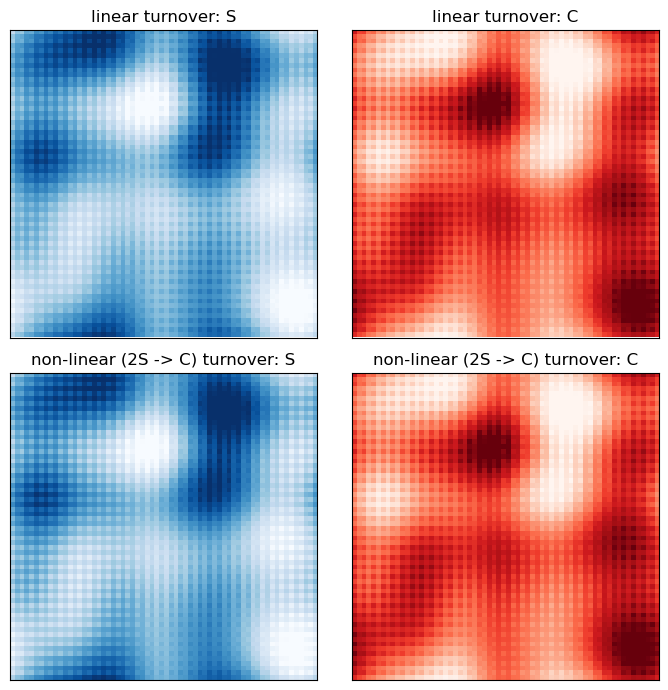

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for row_idx, (cf, title) in enumerate([(cf_D_lin, 'linear turnover'),
                                       (cf_D_mm,  'non-linear (2S -> C) turnover')]):
    for col_idx, (sp_name, cm) in enumerate([('S', 'Blues'), ('C', 'Reds')]):
        ax = axes[row_idx, col_idx]
        fld = np.asarray(cf[col_idx])
        lo, hi = np.percentile(fld, [2.0, 98.0])
        if hi <= lo + 1e-12:
            lo, hi = float(fld.min()), float(fld.max())
            if hi <= lo:
                hi = lo + 1e-6
        ax.imshow(fld, origin='lower', cmap=cm, vmin=lo, vmax=hi)
        ax.set_title(f'{title}: {sp_name}')
        ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


### Cross-check: linear-limit MM = legacy `kon`/`koff`

`linear_turnover_system(kon, koff, n_com)` should match the legacy source up to floating-point roundoff.

In [16]:
# Use the legacy kon/koff path: build params with kon, reactions=None.
N_COM_X = 3
N_GRID_X = 64
LMBDA_X = 0.01
DT_X = 5e-6
BETA_X = N_COM_X / (N_COM_X + 1.0)
N_STEPS_X = 5_000

key = jax.random.PRNGKey(505)
k_chi, k_ic = jax.random.split(key)

chi_X = generate_chi_matrix(N_COM_X, 0.0, 2.0, k_chi)
c0_X = generate_initial_conditions(N_COM_X, N_GRID_X, beta=BETA_X, key=k_ic)

kon = 0.5
params_legacy = build_params(chi_X, N_COM_X, beta=BETA_X, lmbda=LMBDA_X, dt=DT_X,
                             kon=kon)

koff = kon * N_COM_X / BETA_X
rs = linear_turnover_system(kon=kon, koff=koff, n_com=N_COM_X)
params_rxn = build_params(chi_X, N_COM_X, beta=BETA_X, lmbda=LMBDA_X, dt=DT_X,
                          reactions=rs)

cf_legacy = simulate(c0_X, params_legacy, N_GRID_X, N_STEPS_X)
cf_rxn    = simulate(c0_X, params_rxn,    N_GRID_X, N_STEPS_X, rate_law='mass_action')

diff = float(jnp.max(jnp.abs(cf_legacy - cf_rxn)))
print('max |legacy - ReactionSystem| =', diff)
assert diff < 1e-4, f'mismatch too large: {diff}'
print('linear-limit cross-check passed.')

max |legacy - ReactionSystem| = 2.9206275939941406e-06
linear-limit cross-check passed.
